# Efficacité énergétique du hardware ML

Analyse des processeurs/accélérateurs (GPU/ASIC) pour IA : performances FP16/BF16, TDP et efficacité (TFLOPS/W). Données : `../data/ml_hardware/ml_hardware.csv`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

root = Path('..') / 'data' / 'ml_hardware'
HW_PATH = root / 'ml_hardware.csv'

hw = pd.read_csv(HW_PATH)
# Nettoyage des colonnes principales
hw['Release date'] = pd.to_datetime(hw['Release date'], errors='coerce')
hw['TDP (W)'] = pd.to_numeric(hw['TDP (W)'], errors='coerce')
hw['Tensor-FP16/BF16 performance (FLOP/s)'] = pd.to_numeric(hw['Tensor-FP16/BF16 performance (FLOP/s)'], errors='coerce')

hw = hw.dropna(subset=['TDP (W)', 'Tensor-FP16/BF16 performance (FLOP/s)'])
hw['TFLOPS_FP16'] = hw['Tensor-FP16/BF16 performance (FLOP/s)'] / 1e12
hw['TFLOPS_per_W'] = hw['TFLOPS_FP16'] / hw['TDP (W)']

hw[['Hardware name','Manufacturer','Release date','TFLOPS_FP16','TDP (W)','TFLOPS_per_W']].head()


,Hardware name,Manufacturer,Release date,TFLOPS_FP16,TDP (W),TFLOPS_per_W
0,Amazon Trainium3,Amazon AWS,2025-12-02,671.0,700.0,0.958571
1,Google TPU v7 Ironwood,Google,2025-11-06,2307.0,960.0,2.403125
3,NVIDIA GB300 (Blackwell Ultra),NVIDIA,2025-08-22,2500.0,1400.0,1.785714
4,NVIDIA B300 (Blackwell Ultra),NVIDIA,2025-08-22,2250.0,1100.0,2.045455
5,AMD Instinct MI355X,AMD,2025-06-12,2516.6,1400.0,1.797571


/tmp/ipykernel_58149/2114619100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=best, x='TFLOPS_per_W', y='Hardware name', palette='crest')


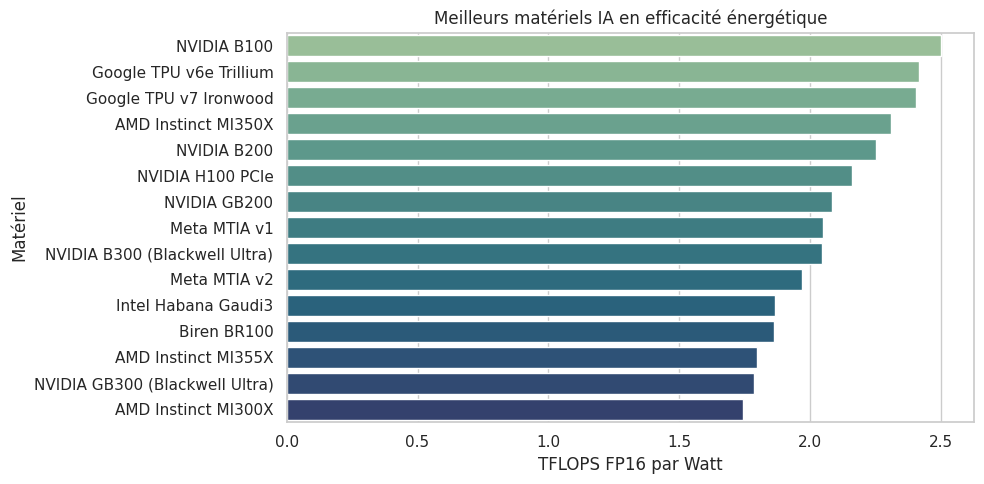

In [2]:
# Top 15 du ratio performance/puissance
best = hw.sort_values('TFLOPS_per_W', ascending=False).head(15)
ax = sns.barplot(data=best, x='TFLOPS_per_W', y='Hardware name', palette='crest')
ax.set_xlabel('TFLOPS FP16 par Watt')
ax.set_ylabel('Matériel')
ax.set_title('Meilleurs matériels IA en efficacité énergétique')
plt.tight_layout(); plt.show()


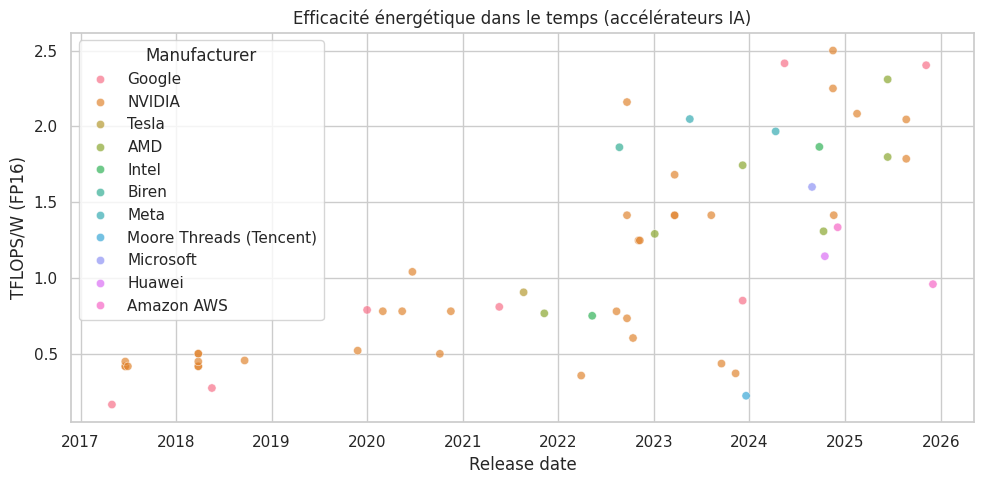

In [3]:
# Évolution temporelle de l’efficacité
hw_sorted = hw.dropna(subset=['Release date']).sort_values('Release date')
ax = sns.scatterplot(data=hw_sorted, x='Release date', y='TFLOPS_per_W', hue='Manufacturer', alpha=0.7)
ax.set_ylabel('TFLOPS/W (FP16)')
ax.set_title('Efficacité énergétique dans le temps (accélérateurs IA)')
plt.tight_layout(); plt.show()


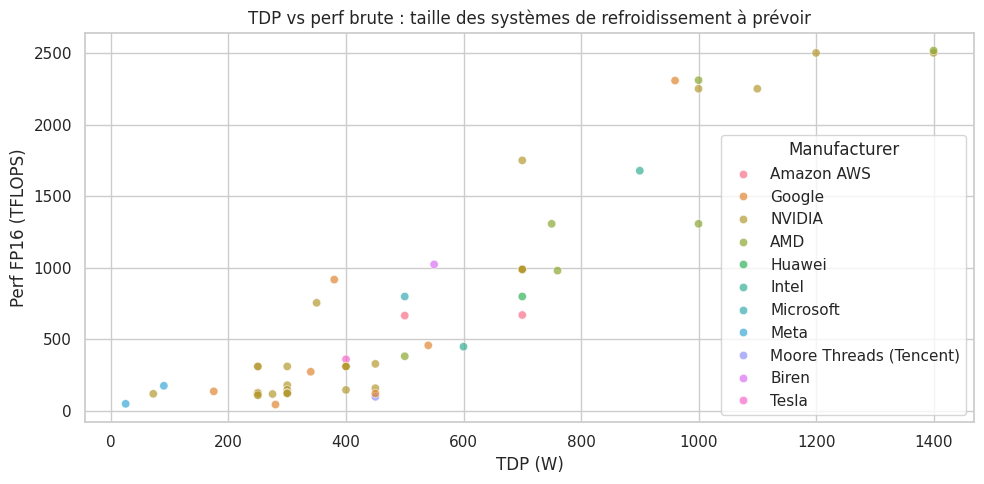

In [4]:
# Trade-off puissance vs performance absolue
ax = sns.scatterplot(data=hw, x='TDP (W)', y='TFLOPS_FP16', hue='Manufacturer', alpha=0.7)
ax.set_xlabel('TDP (W)')
ax.set_ylabel('Perf FP16 (TFLOPS)')
ax.set_title('TDP vs perf brute : taille des systèmes de refroidissement à prévoir')
plt.tight_layout(); plt.show()


## Lecture rapide
- Le ratio TFLOPS/W varie fortement : les meilleurs matériels dépassent largement la moyenne, ce qui réduit les besoins électriques et de refroidissement.
- L’efficacité progresse dans le temps mais reste hétérogène selon constructeurs et générations.
- Le couple TDP/performance montre que les plus gros accélérateurs exigent des infrastructures électriques et thermiques conséquentes : à intégrer dans les scénarios “energy wall”.
